<span style="color:red; font-size:16px; font-weight:bold">Instruction:</span><br>
Students must write their solutions exclusively in the sections marked with:<br>
<span style="color:red; font-size:15px; font-weight:bold"># CODE HERE !<br><br>
###########
</span>

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle

In [2]:
# For helper functions only
# Write your helper functions here (if any)
# CODE HERE !

###########

### ────────────────────────────────────────────────────────────────
### <span style="color:blue; font-size:18px; font-weight:bold">Initialization Function</span>
###### <span style="color:red; font-size:16px">**Points:** ___ / 1</span>
###### <span style="color:green; font-size:16px">**Comments:**</span>

### ────────────────────────────────────────────────────────────────
### <span style="color:blue; font-size:18px; font-weight:bold">Preprocess Function</span>
###### <span style="color:red; font-size:16px">**Points:** ___ / 3</span>
###### <span style="color:green; font-size:16px">**Comments:**</span>

### ────────────────────────────────────────────────────────────────
### <span style="color:blue; font-size:18px; font-weight:bold">Feature Creation Function</span>
###### <span style="color:red; font-size:16px">**Points:** ___ / 2</span>
###### <span style="color:green; font-size:16px">**Comments:**</span>

### ────────────────────────────────────────────────────────────────
### <span style="color:blue; font-size:18px; font-weight:bold">Cross Validation Function</span>
###### <span style="color:red; font-size:16px">**Points:** ___ / 5</span>
###### <span style="color:green; font-size:16px">**Comments:**</span>

### ────────────────────────────────────────────────────────────────
### <span style="color:blue; font-size:18px; font-weight:bold">Training Function</span>
###### <span style="color:red; font-size:16px">**Points:** ___ / 2</span>
###### <span style="color:green; font-size:16px">**Comments:**</span>

### ────────────────────────────────────────────────────────────────
### <span style="color:blue; font-size:18px; font-weight:bold">TSS Function</span>
###### <span style="color:red; font-size:16px">**Points:** ___ / 2</span>
###### <span style="color:green; font-size:16px">**Comments:**</span>

In [3]:
# __init__() function should initialize all your variables
# _____ 1 pt _____
class my_svm():
    def __init__(self, x_:list, y_:list, data_folder:str):
        # CODE HERE !
        self.x = np.array(x_) # features
        self.y = np.array(y_) # labels
        self.data_folder = data_folder
        ###########
        pass
#############################################################


    # preprocess() function:
    # _____ 1 pt _____
    #  1) normalizes the data, 
    # _____ 1 pt _____
    #  2) removes missing values
    # _____ 1 pt _____
    #  3) assign labels to target
    def preprocess(self):
        # CODE HERE !
        mask = ~np.isnan(self.x).any(axis=1) & ~np.isnan(self.y)
        self.x = self.x[mask]
        self.y = self.y[mask]

        # call StandardScalar for normalization
        scalar = StandardScaler()

        # rewrite self.x with preprocessed values
        self.x = scalar.fit_transform(self.x)
        ###########
        return self.x, self.y
#############################################################


    # _____ 2 pt _____
    # feature_creation() function takes as input the features set label (e.g. FS-I, FS-II, FS-III, FS-IV)
    # and creates 2 D array of corresponding features 
    # for both positive and negative observations.
    # this array will be input to the svm model
    # For instance, if the input is FS-I, the output is a 2-d array with features corresponding to 
    # FS-I for both negative and positive class observations
    def feature_creation(self, fs_value):
        # CODE HERE !
        # map each fs_value to columns
        feature_map = {"FS-I": ("main_timechange.npy", slice(0,18)), 
                       "FS-II": ("main_timechange.npy", slice(18,90)), 
                       "FS-III": ("historical.npy", slice(0,1)),
                       "FS-IV": ("maxmin.npy", slice(0,18))}
        
        # split input string of commas and whitespace in case multiple
        requested_fs = [fs.strip() for fs in fs_value.split(',')]

        # initialize pos, neg arrays
        pos_features_list = []
        neg_features_list = []

        # check that fs_value is valid; if it is then get filename and column slice from feature_map
        for fs in requested_fs:
            if fs not in feature_map:
                raise ValueError(f"Invalid feature set {fs}")
            
            filename, cols_slice = feature_map[fs]

            pos_path = os.path.join(self.data_folder, f"pos_features_{filename}")
            neg_path = os.path.join(self.data_folder, f"neg_features_{filename}")

            # load pos, neg data
            pos_data = np.load(pos_path)
            neg_data = np.load(neg_path)

            # extract columns/slices
            pos_fs_data = pos_data[:, cols_slice]
            neg_fs_data = neg_data[:, cols_slice]

            # append data to feature arrays
            pos_features_list.append(pos_fs_data)
            neg_features_list.append(neg_fs_data)
        
        pos_features_combined = np.hstack(pos_features_list)
        neg_features_combined = np.hstack(neg_features_list)

        features_array = np.vstack((pos_features_combined, neg_features_combined))

        ###########
        return features_array
#############################################################


    # cross_validation() function splits the data into train and test splits,
    # _____ 1 pt _____
    # Use k-fold with k=10
    # _____ 1 pt _____
    # the svm is trained on training set and tested on test set
    # _____ 1 pt _____
    # the output is the average accuracy across all train test splits.
    # _____ 2 pt _____ (Integration of the two functions)
    def cross_validation(self, X,y):
        # CODE HERE !
        # X and y should be preprocessed in main()
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        tss_scores = []

        for train_idx, test_idx in kf.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model = self.training(X_train, y_train)

            y_pred = model.predict(X_test)

            tss_score = self.tss(y_test, y_pred)
            tss_scores.append(tss_score)

        avg_tss = np.mean(tss_scores)
        ###########
        # call training function
        # call tss function
        return avg_tss
#############################################################


    # _____ 2 pt _____
    #training() function trains a SVM classification model on input features and corresponding target
    def training(self, X_train, y_train):
        # CODE HERE !
        # use imported SVC; can change kernel type, C value, gamma value
        model = SVC(kernel="rbf", C = 1, gamma = 'scale')
        model.fit(X_train, y_train)
        ###########
        return model
#############################################################


    # _____ 2 pt _____
    # tss() function computes the accuracy of predicted outputs (i.e target prediction on test set)
    # using the TSS measure given in the document
    def tss(self, y_true, y_pred):
        # CODE HERE !

        # calculate confusion matrix elements
        TP = np.sum((y_true == 1) & (y_pred == 1))
        TN = np.sum((y_true == 0) & (y_pred == 0))
        FP = np.sum((y_true == 0) & (y_pred == 1))
        FN = np.sum((y_true == 1) & (y_pred == 0))

        # check for division by 0
        if TP + FN > 0:
            true_positive = TP / (TP + FN)
        else:
            true_positive = 0
        
        if FP + TN > 0:
            false_positive = FP / (FP + TN)
        else:
            false_positive = 0

        tss_score = true_positive - false_positive
        ###########
        return tss_score

### ────────────────────────────────────────────────────────────────
### <span style="color:blue; font-size:18px; font-weight:bold">Feature Experiment Function</span>
###### <span style="color:red; font-size:16px">**Points:** ___ / 4</span>
###### <span style="color:green; font-size:16px">**Comments:**</span>

In [4]:
# _____ 1 pt _____ (Runs all feature set combinations)
# _____ 1 pt _____ (Reports mean/std TSS)
# _____ 1 pt _____ (Produces confusion matrices)
# _____ 1 pt _____ (Generates bar chart of fold results)

# feature_experiment() function executes experiments with all 4 feature sets.
# svm is trained (and tested) on 2010 dataset with all 4 feature set combinations
# the output of this function is : 
#  1) TSS average scores (mean std) for k-fold validation printed out on console.
#  2) Confusion matrix for TP, FP, TN, FN. See assignment document 
#  3) A chart showing TSS scores for all folds of CV. 
#     This means that for each fold, compute the TSS score on test set for that fold, and plot it.
#     The number of folds will decide the number of points on this chart (i.e 10)
#
# Above 3 charts are produced for all feature combinations
#  4) The function prints the best performing feature set combination

def feature_experiment():
    # CODE HERE !
    data_folder = "data-2010-15"
    svm_model = my_svm([], [], data_folder)
    feature_combos = [
        ["FS-I"],
        ["FS-II"],
        ["FS-III"],
        ["FS-IV"],
        ["FS-I", "FS-II"],
        ["FS-I", "FS-III"],
        ["FS-I", "FS-IV"],
        ["FS-II", "FS-III"],
        ["FS-II", "FS-IV"],
        ["FS-III", "FS-IV"],
        ["FS-I", "FS-II", "FS-III"],
        ["FS-I", "FS-II", "FS-IV"],
        ["FS-I", "FS-III", "FS-IV"],
        ["FS-II", "FS-III", "FS-IV"],
        ["FS-I", "FS-II", "FS-III", "FS-IV"]
    ]

    # store results for comparison
    results = []
    all_conf_matrices = []

    # for plotting bar graph of tss
    fig, axes = plt.subplots(3, 5, figsize=(25,12))
    axes = axes.flatten()

    for i, combo in enumerate(feature_combos):
        # create feature array based on combo
        X_features = svm_model.feature_creation(",".join(combo))

        # create target labels (1 for positive, 0 for negative)
        pos_labels = np.load(f"{data_folder}/pos_class.npy", allow_pickle=True)
        neg_labels = np.load(f"{data_folder}/neg_class.npy", allow_pickle=True)

        # combine positive/negative labels
        y_labels = np.concatenate([np.ones(len(pos_labels)), np.zeros(len(neg_labels))])

        # assign to SVM
        svm_model.x = X_features
        svm_model.y = y_labels

        # preprocess
        X_preprocessed, y_preprocessed = svm_model.preprocess()

        # use cross_validation for average TSS
        avg_tss = svm_model.cross_validation(X_preprocessed, y_preprocessed)
        

        #run fold manually for confusion matrixes and and fold TSS
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        fold_tss_scores = []
        all_y_true = []
        all_y_pred = []

        TP_total = FP_total = TN_total = FN_total = 0

        for train_idx, test_idx in kf.split(X_preprocessed):
            X_train, X_test = X_preprocessed[train_idx], X_preprocessed[test_idx]
            y_train, y_test = y_preprocessed[train_idx], y_preprocessed[test_idx]

            model = svm_model.training(X_train, y_train)
            y_pred = model.predict(X_test)

            fold_tss_scores.append(svm_model.tss(y_test, y_pred))
            all_y_true.extend(y_test)
            all_y_pred.extend(y_pred)
            
            TP_total += np.sum((y_test == 1) & (y_pred == 1))
            FP_total += np.sum((y_test == 0) & (y_pred == 1))
            TN_total += np.sum((y_test == 0) & (y_pred == 0))
            FN_total += np.sum((y_test == 1) & (y_pred == 0))
        
        # Mean and Std of TSS
        mean_tss = np.mean(fold_tss_scores)
        std_tss = np.std(fold_tss_scores)

        # print on console
        print(f"Feature combo: {', '.join(combo)} | Mean TSS: {mean_tss:.4f} | Std TSS: {std_tss:.4f}")
        
        conf_mat = np.array([[TN_total, FP_total],
                             [FN_total, TP_total]])
        all_conf_matrices.append((conf_mat, combo, avg_tss))

        # Plot bar chart of fold TSS
        ax = axes[i]
        ax.bar(range(1, len(fold_tss_scores) + 1), fold_tss_scores, color="skyblue")
        ax.set_title(f"{','.join(combo)}\nAvg TSS = {avg_tss:.3f}")
        ax.set_ylim(-1,1)
        ax.set_xlabel("Fold")
        ax.set_ylabel("TSS")

        results.append((combo, avg_tss))         

    plt.tight_layout()
    plt.show()

    # Plot conf matrices
    fig_cm, axes_cm = plt.subplots(3, 5, figsize=(25,12))
    axes_cm = axes_cm.flatten()
    
    for i, (cm, combo, avg_tss) in enumerate(all_conf_matrices):
        ax = axes_cm[i]

        # sklearn confusion matrix display
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Flare (0)", "Flare (1)"])
        
        # plot into the existing subplot axis
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        
        # set subplot title and adjust layout
        ax.set_title(f"{', '.join(combo)}\nMean={avg_tss:.3f}", fontsize=11)


    plt.tight_layout()
    plt.show()

    # find best performing feature combo
    best_score = 0
    best_combo = 0
    for combo, score in results:
        if score > best_score:
            best_score = score
            best_combo = combo

    print(f"Best performing feature set: {','.join(best_combo)} with Avg TSS = {best_score:.4f}")
    ###########
    return


### ────────────────────────────────────────────────────────────────
### <span style="color:blue; font-size:18px; font-weight:bold">Data Experiment Function</span>
###### <span style="color:red; font-size:16px">**Points:** ___ / 4</span>
###### <span style="color:green; font-size:16px">**Comments:**</span>

In [5]:
# _____ 1 pt _____ (Runs on both datasets)
# _____ 1 pt _____ (Uses best feature set)
# _____ 1 pt _____ (Reports mean/std TSS)
# _____ 1 pt _____ (Produces confusion matrices + fold charts)

# data_experiment() function executes 2 experiments with 2 data sets.
# svm is trained (and tested) on both 2010 data and 2020 data
# the output of this function is : 
#  1) TSS average scores for k-fold validation printed out on console.
#  2) Confusion matrix for TP, FP, TN, FN. See assignment document 
#  3) A chart showing TSS scores for all folds of CV. 
#     This means that for each fold, compute the TSS score on test set for that fold, and plot it.
#     The number of folds will decide the number of points on this chart (i.e. 10)
# above 3 charts are produced for both datasets
# feature set for this experiment should be the 
# best performing feature set combination from feature_experiment()

def data_experiment():
    # Both datasets to test
    data_folders = ["data-2010-15", "data-2020-24"]

    # loop through all datasets
    for data_folder in data_folders:
        print("\n")
        print(f" Running feature experiments on: {data_folder}")

        # Initialize SVM model
        svm_model = my_svm([], [], data_folder)

        # Define all feature set combinations
        feature_combos = [
            ["FS-I"],
            ["FS-II"],
            ["FS-III"],
            ["FS-IV"],
            ["FS-I", "FS-II"],
            ["FS-I", "FS-III"],
            ["FS-I", "FS-IV"],
            ["FS-II", "FS-III"],
            ["FS-II", "FS-IV"],
            ["FS-III", "FS-IV"],
            ["FS-I", "FS-II", "FS-III"],
            ["FS-I", "FS-II", "FS-IV"],
            ["FS-I", "FS-III", "FS-IV"],
            ["FS-II", "FS-III", "FS-IV"],
            ["FS-I", "FS-II", "FS-III", "FS-IV"]
        ]

        # Storage for results
        results = []
        all_conf_matrices = []

        # Prepare figure for TSS bar charts
        fig, axes = plt.subplots(3, 5, figsize=(25, 12))
        axes = axes.flatten()

        # === Run the same experiment for every feature combination ===
        for i, combo in enumerate(feature_combos):
            # Create feature array
            X_features = svm_model.feature_creation(",".join(combo))

            # Load labels (1 = pos, 0 = neg)
            pos_labels = np.load(f"{data_folder}/pos_class.npy", allow_pickle=True)
            neg_labels = np.load(f"{data_folder}/neg_class.npy", allow_pickle=True)
            y_labels = np.concatenate([np.ones(len(pos_labels)), np.zeros(len(neg_labels))])

            svm_model.x = X_features
            svm_model.y = y_labels

            # Preprocess
            X_preprocessed, y_preprocessed = svm_model.preprocess()

            # Cross-validation setup
            kf = KFold(n_splits=5, shuffle=True, random_state=42)
            fold_tss_scores = []
            TP_total = FP_total = TN_total = FN_total = 0

            for train_idx, test_idx in kf.split(X_preprocessed):
                X_train, X_test = X_preprocessed[train_idx], X_preprocessed[test_idx]
                y_train, y_test = y_preprocessed[train_idx], y_preprocessed[test_idx]

                model = svm_model.training(X_train, y_train)
                y_pred = model.predict(X_test)

                # Calculate TSS for each fold
                fold_tss_scores.append(svm_model.tss(y_test, y_pred))

                # Accumulate confusion matrix totals
                TP_total += np.sum((y_test == 1) & (y_pred == 1))
                FP_total += np.sum((y_test == 0) & (y_pred == 1))
                TN_total += np.sum((y_test == 0) & (y_pred == 0))
                FN_total += np.sum((y_test == 1) & (y_pred == 0))

            # Mean and Std of TSS
            mean_tss = np.mean(fold_tss_scores)
            std_tss = np.std(fold_tss_scores)

            # print on console
            print(f"Feature combo: {', '.join(combo)} | Mean TSS: {mean_tss:.4f} | Std TSS: {std_tss:.4f}")

            # Save confusion matrix
            conf_mat = np.array([[TN_total, FP_total],
                                 [FN_total, TP_total]])
            all_conf_matrices.append((conf_mat, combo, mean_tss, std_tss))

            # plot bar chart for TSS per fold
            ax = axes[i]
            ax.bar(range(1, len(fold_tss_scores) + 1), fold_tss_scores, color="skyblue")
            ax.set_title(f"{', '.join(combo)}\nMean={mean_tss:.3f} ± {std_tss:.3f}")
            ax.set_ylim(-1, 1)
            ax.set_xlabel("Fold")
            ax.set_ylabel("TSS")

            # Store combo result
            results.append((combo, mean_tss, std_tss))

        # Show all bar charts together
        plt.tight_layout()
        plt.show()

        # Plot confusion matrices
        fig_cm, axes_cm = plt.subplots(3, 5, figsize=(25, 12))
        axes_cm = axes_cm.flatten()

        for i, (cm, combo, mean_tss, std_tss) in enumerate(all_conf_matrices):
            ax = axes_cm[i]

            # sklearn confusion matrix display
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Flare (0)", "Flare (1)"])
            
            # plot into the existing subplot axis
            disp.plot(ax=ax, cmap="Blues", colorbar=False)
            
            # set subplot title and adjust layout
            ax.set_title(f"{', '.join(combo)}\nMean={mean_tss:.3f}, ± {std_tss:.3f}", fontsize=11)

        plt.tight_layout()
        plt.show()

        # find best-performing combo for given dataset
        best_score = 0
        best_combo = 0
        best_std = 0
        for combo, mean_tss, std_tss in results:
            if mean_tss > best_score:
                best_score = mean_tss
                best_combo = combo
                best_std = std_tss

        print(f"\nBest performing feature set for {data_folder}: {', '.join(best_combo)} with Avg TSS = {best_score:.4f} ± {best_std:.4f}")
    
    print("\n Data experiments complete for all datasts")
    return



### ────────────────────────────────────────────────────────────────
### <span style="color:blue; font-size:18px; font-weight:bold">Main Execution</span>
###### <span style="color:red; font-size:16px">**Points:** ___ / 2</span>
###### <span style="color:green; font-size:16px">**Comments:**</span>

Feature combo: FS-I | Mean TSS: 0.7317 | Std TSS: 0.0199
Feature combo: FS-II | Mean TSS: 0.6045 | Std TSS: 0.0382
Feature combo: FS-III | Mean TSS: 0.0000 | Std TSS: 0.0000
Feature combo: FS-IV | Mean TSS: 0.7652 | Std TSS: 0.0587
Feature combo: FS-I, FS-II | Mean TSS: 0.7124 | Std TSS: 0.0332
Feature combo: FS-I, FS-III | Mean TSS: 0.7317 | Std TSS: 0.0199
Feature combo: FS-I, FS-IV | Mean TSS: 0.7851 | Std TSS: 0.0384
Feature combo: FS-II, FS-III | Mean TSS: 0.6045 | Std TSS: 0.0382
Feature combo: FS-II, FS-IV | Mean TSS: 0.7341 | Std TSS: 0.0307
Feature combo: FS-III, FS-IV | Mean TSS: 0.7652 | Std TSS: 0.0587
Feature combo: FS-I, FS-II, FS-III | Mean TSS: 0.7124 | Std TSS: 0.0332
Feature combo: FS-I, FS-II, FS-IV | Mean TSS: 0.7399 | Std TSS: 0.0515
Feature combo: FS-I, FS-III, FS-IV | Mean TSS: 0.7851 | Std TSS: 0.0384
Feature combo: FS-II, FS-III, FS-IV | Mean TSS: 0.7341 | Std TSS: 0.0307
Feature combo: FS-I, FS-II, FS-III, FS-IV | Mean TSS: 0.7399 | Std TSS: 0.0515


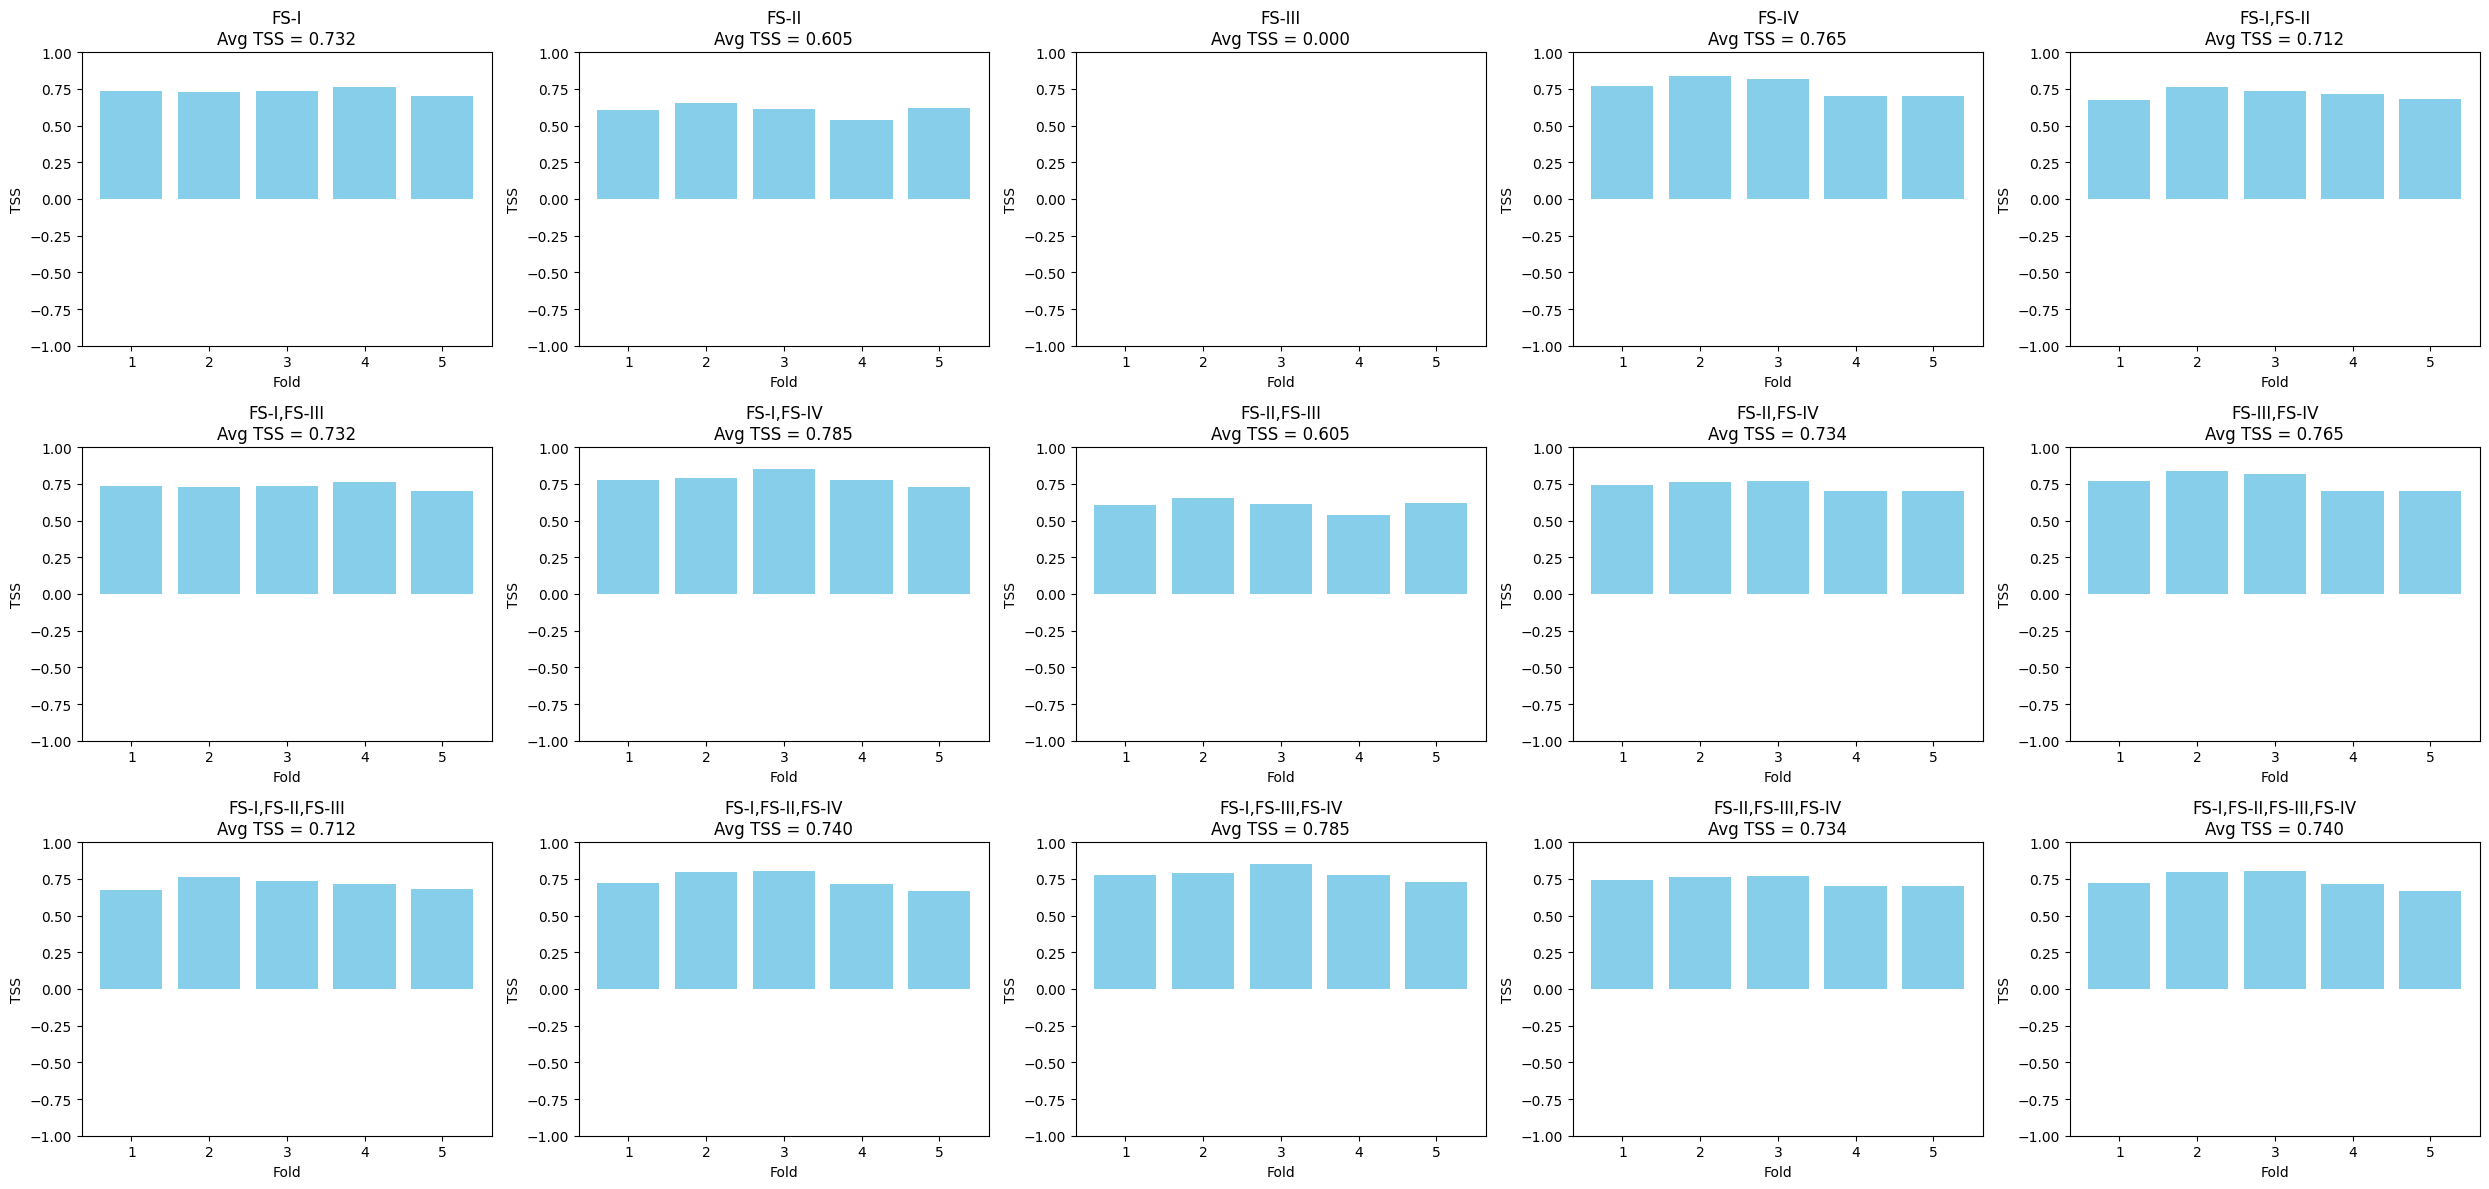

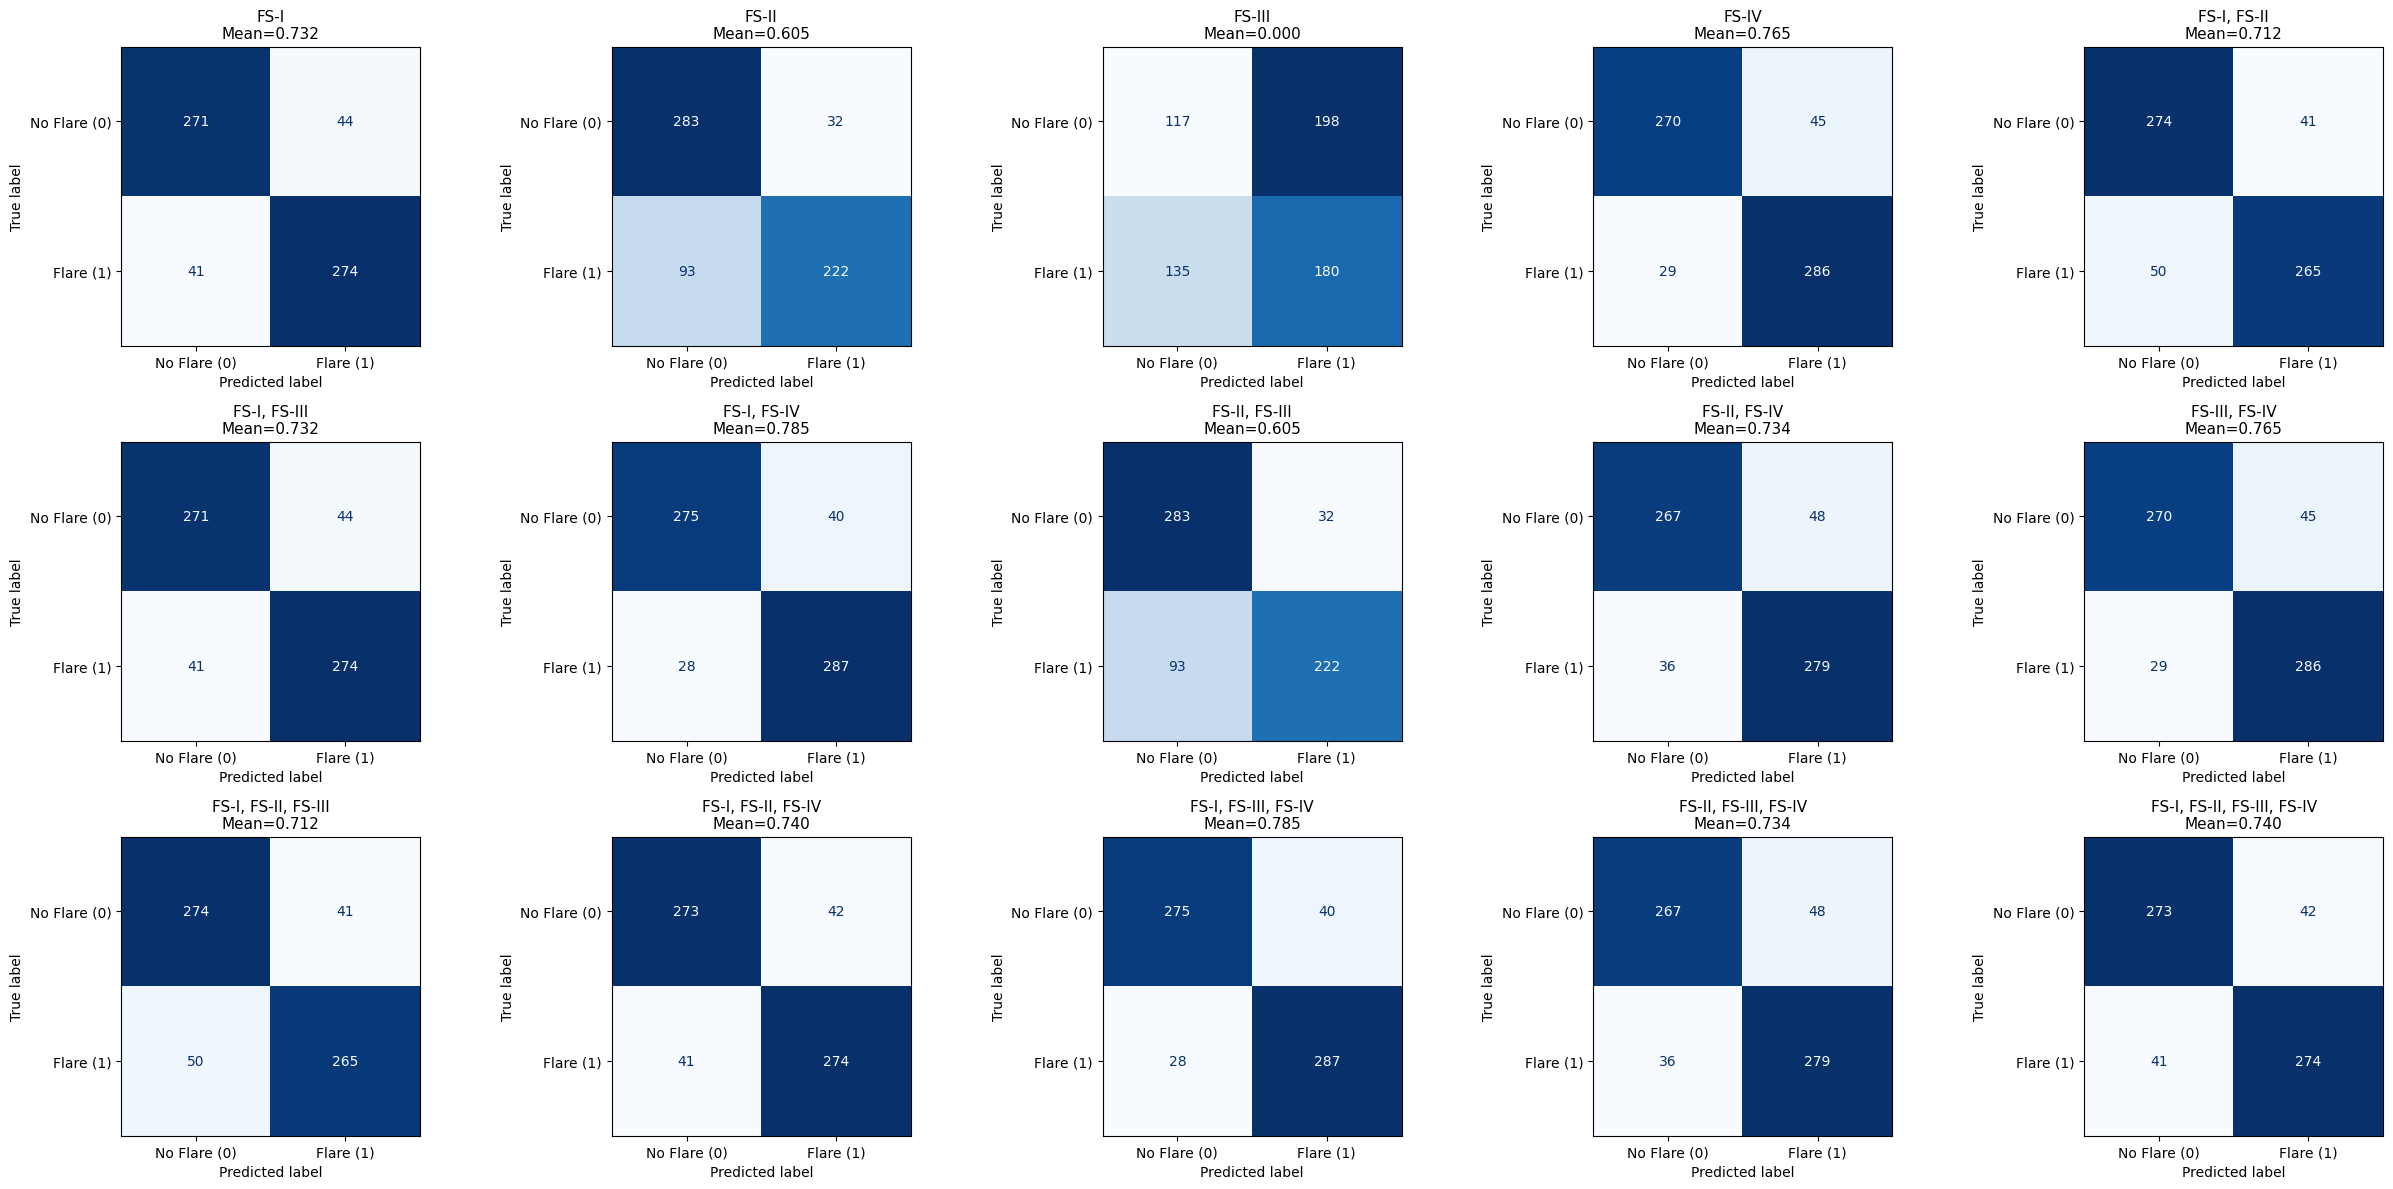

Best performing feature set: FS-I,FS-IV with Avg TSS = 0.7851


 Running feature experiments on: data-2010-15
Feature combo: FS-I | Mean TSS: 0.7317 | Std TSS: 0.0199
Feature combo: FS-II | Mean TSS: 0.6045 | Std TSS: 0.0382
Feature combo: FS-III | Mean TSS: 0.0000 | Std TSS: 0.0000
Feature combo: FS-IV | Mean TSS: 0.7652 | Std TSS: 0.0587
Feature combo: FS-I, FS-II | Mean TSS: 0.7124 | Std TSS: 0.0332
Feature combo: FS-I, FS-III | Mean TSS: 0.7317 | Std TSS: 0.0199
Feature combo: FS-I, FS-IV | Mean TSS: 0.7851 | Std TSS: 0.0384
Feature combo: FS-II, FS-III | Mean TSS: 0.6045 | Std TSS: 0.0382
Feature combo: FS-II, FS-IV | Mean TSS: 0.7341 | Std TSS: 0.0307
Feature combo: FS-III, FS-IV | Mean TSS: 0.7652 | Std TSS: 0.0587
Feature combo: FS-I, FS-II, FS-III | Mean TSS: 0.7124 | Std TSS: 0.0332
Feature combo: FS-I, FS-II, FS-IV | Mean TSS: 0.7399 | Std TSS: 0.0515
Feature combo: FS-I, FS-III, FS-IV | Mean TSS: 0.7851 | Std TSS: 0.0384
Feature combo: FS-II, FS-III, FS-IV | Mean TSS: 0.734

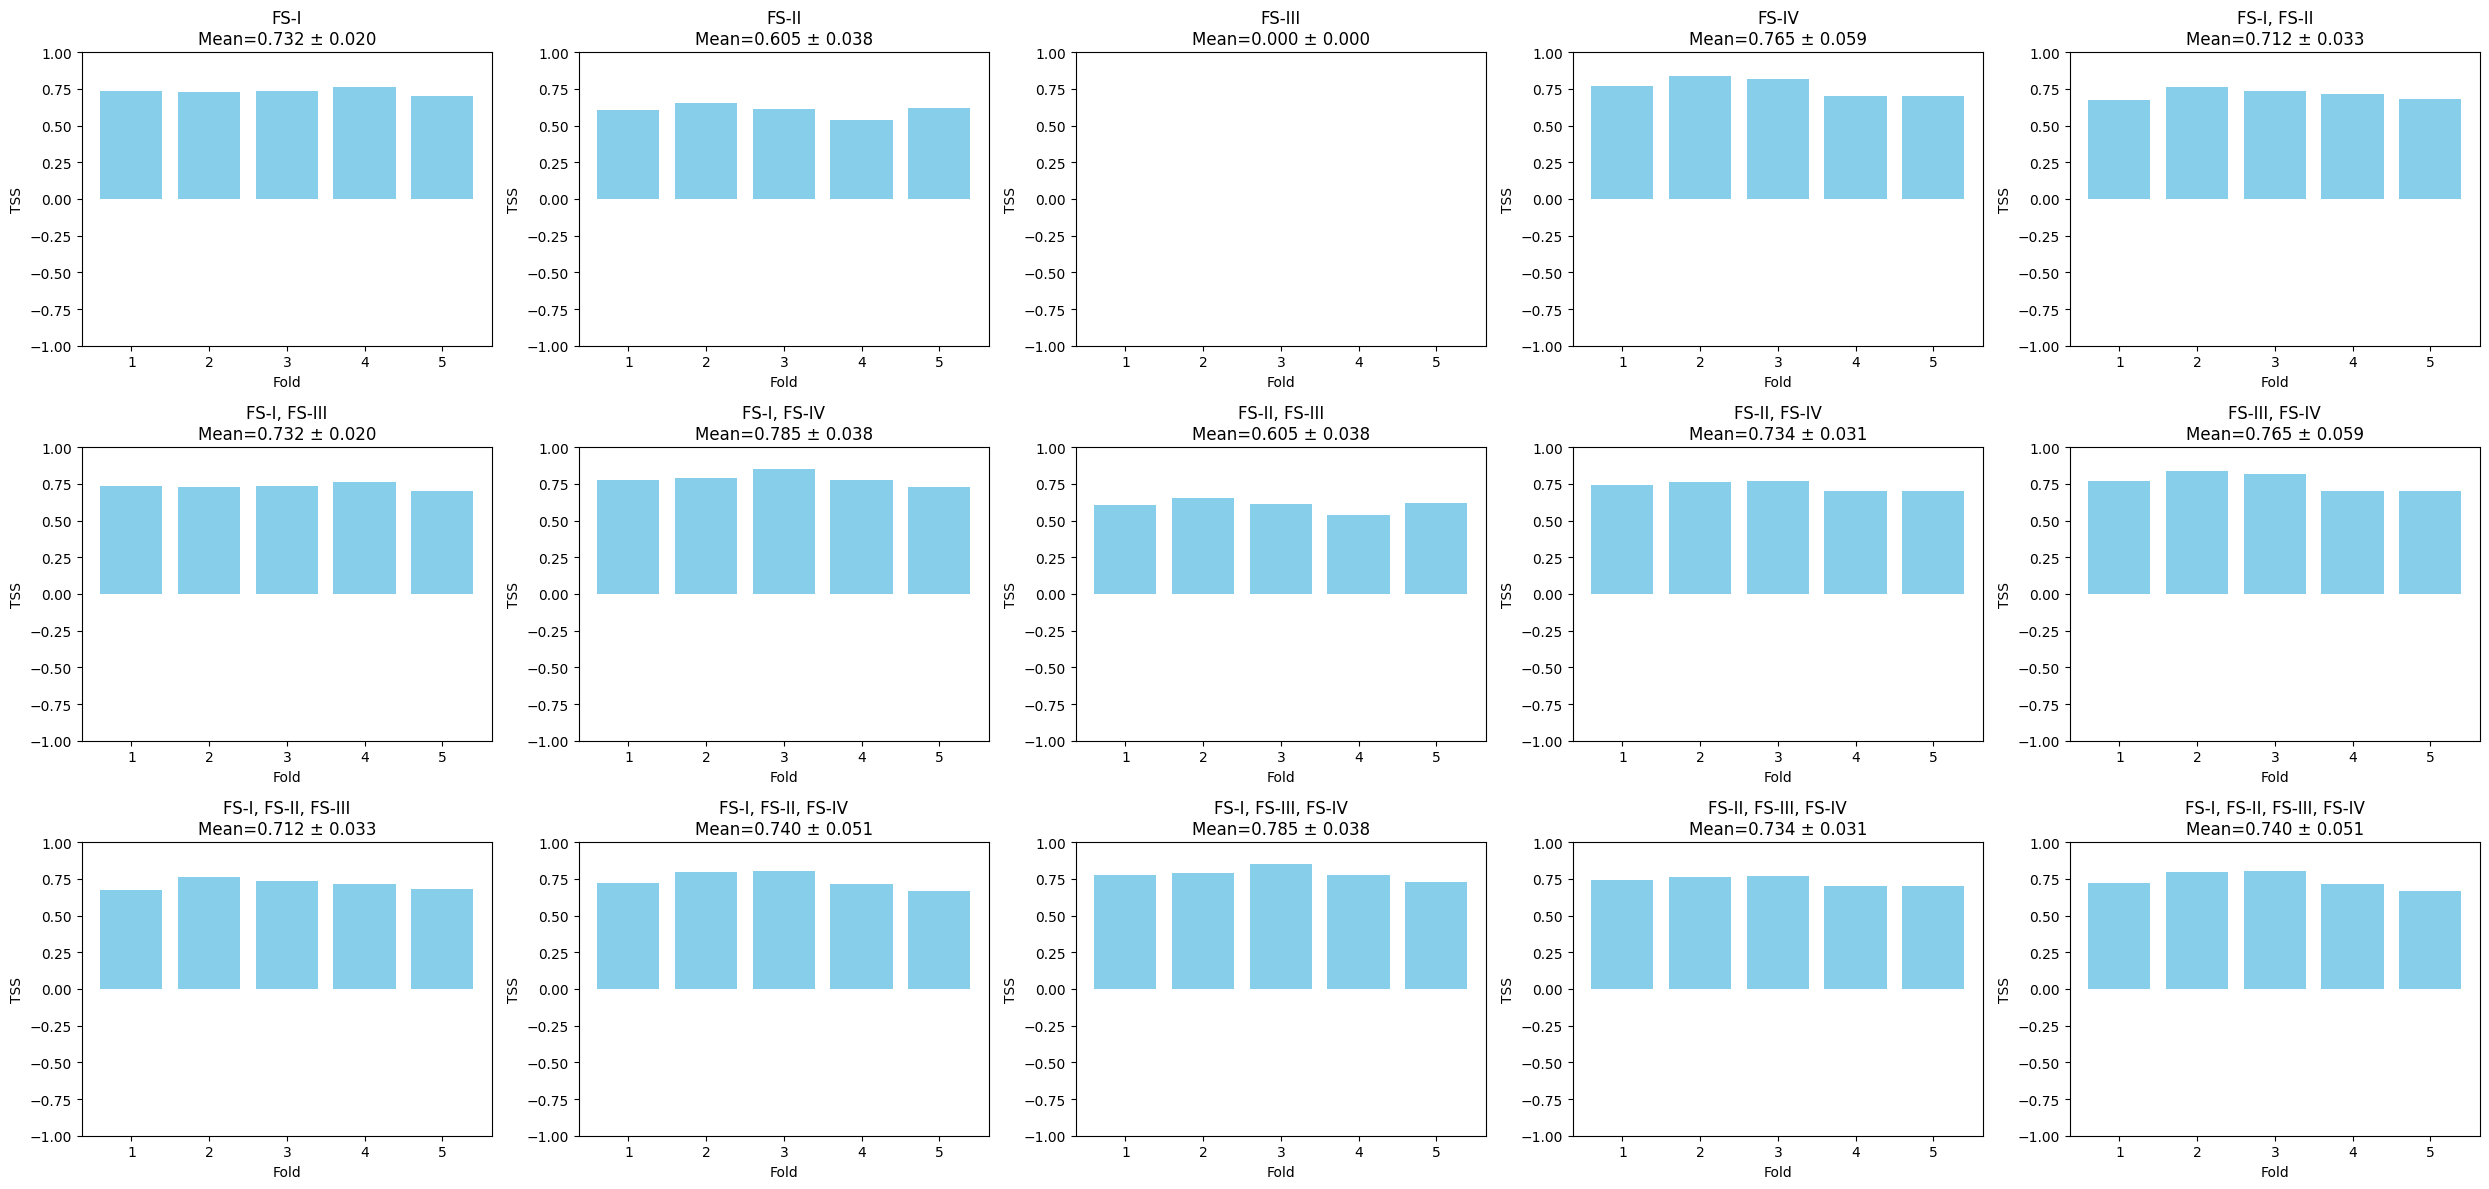

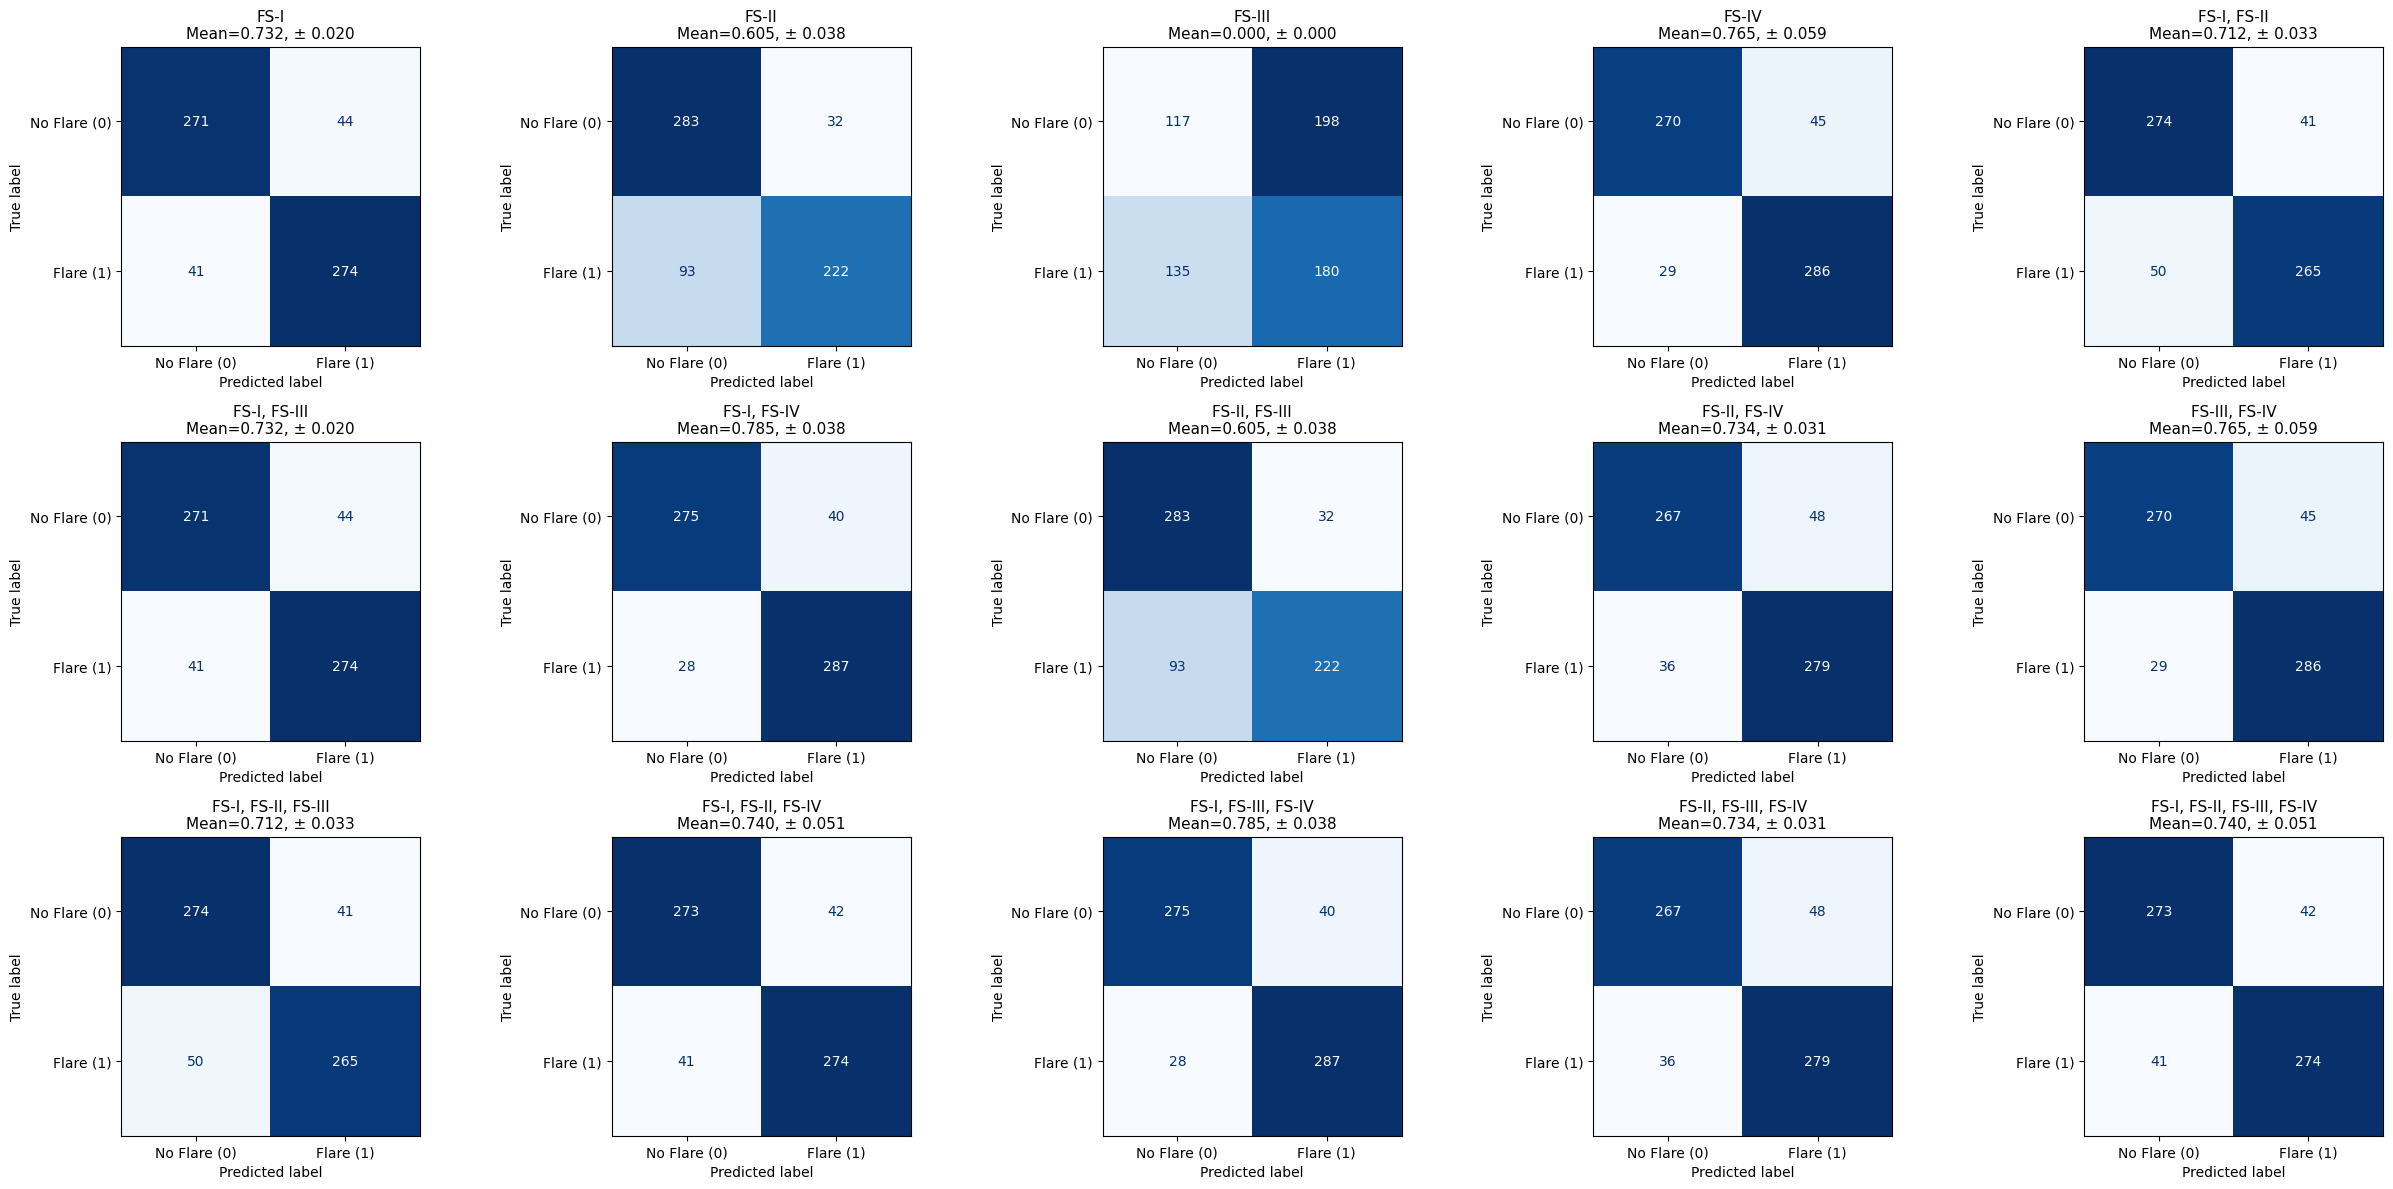


Best performing feature set for data-2010-15: FS-I, FS-IV with Avg TSS = 0.7851 ± 0.0384


 Running feature experiments on: data-2020-24
Feature combo: FS-I | Mean TSS: 0.4724 | Std TSS: 0.1693
Feature combo: FS-II | Mean TSS: 0.5336 | Std TSS: 0.0848
Feature combo: FS-III | Mean TSS: 0.0000 | Std TSS: 0.0000
Feature combo: FS-IV | Mean TSS: 0.6907 | Std TSS: 0.0284
Feature combo: FS-I, FS-II | Mean TSS: 0.6910 | Std TSS: 0.1017
Feature combo: FS-I, FS-III | Mean TSS: 0.4724 | Std TSS: 0.1693
Feature combo: FS-I, FS-IV | Mean TSS: 0.5710 | Std TSS: 0.1682
Feature combo: FS-II, FS-III | Mean TSS: 0.5336 | Std TSS: 0.0848
Feature combo: FS-II, FS-IV | Mean TSS: 0.6625 | Std TSS: 0.0368
Feature combo: FS-III, FS-IV | Mean TSS: 0.6907 | Std TSS: 0.0284
Feature combo: FS-I, FS-II, FS-III | Mean TSS: 0.6910 | Std TSS: 0.1017
Feature combo: FS-I, FS-II, FS-IV | Mean TSS: 0.6514 | Std TSS: 0.0603
Feature combo: FS-I, FS-III, FS-IV | Mean TSS: 0.5710 | Std TSS: 0.1682
Feature combo: FS-II, FS-

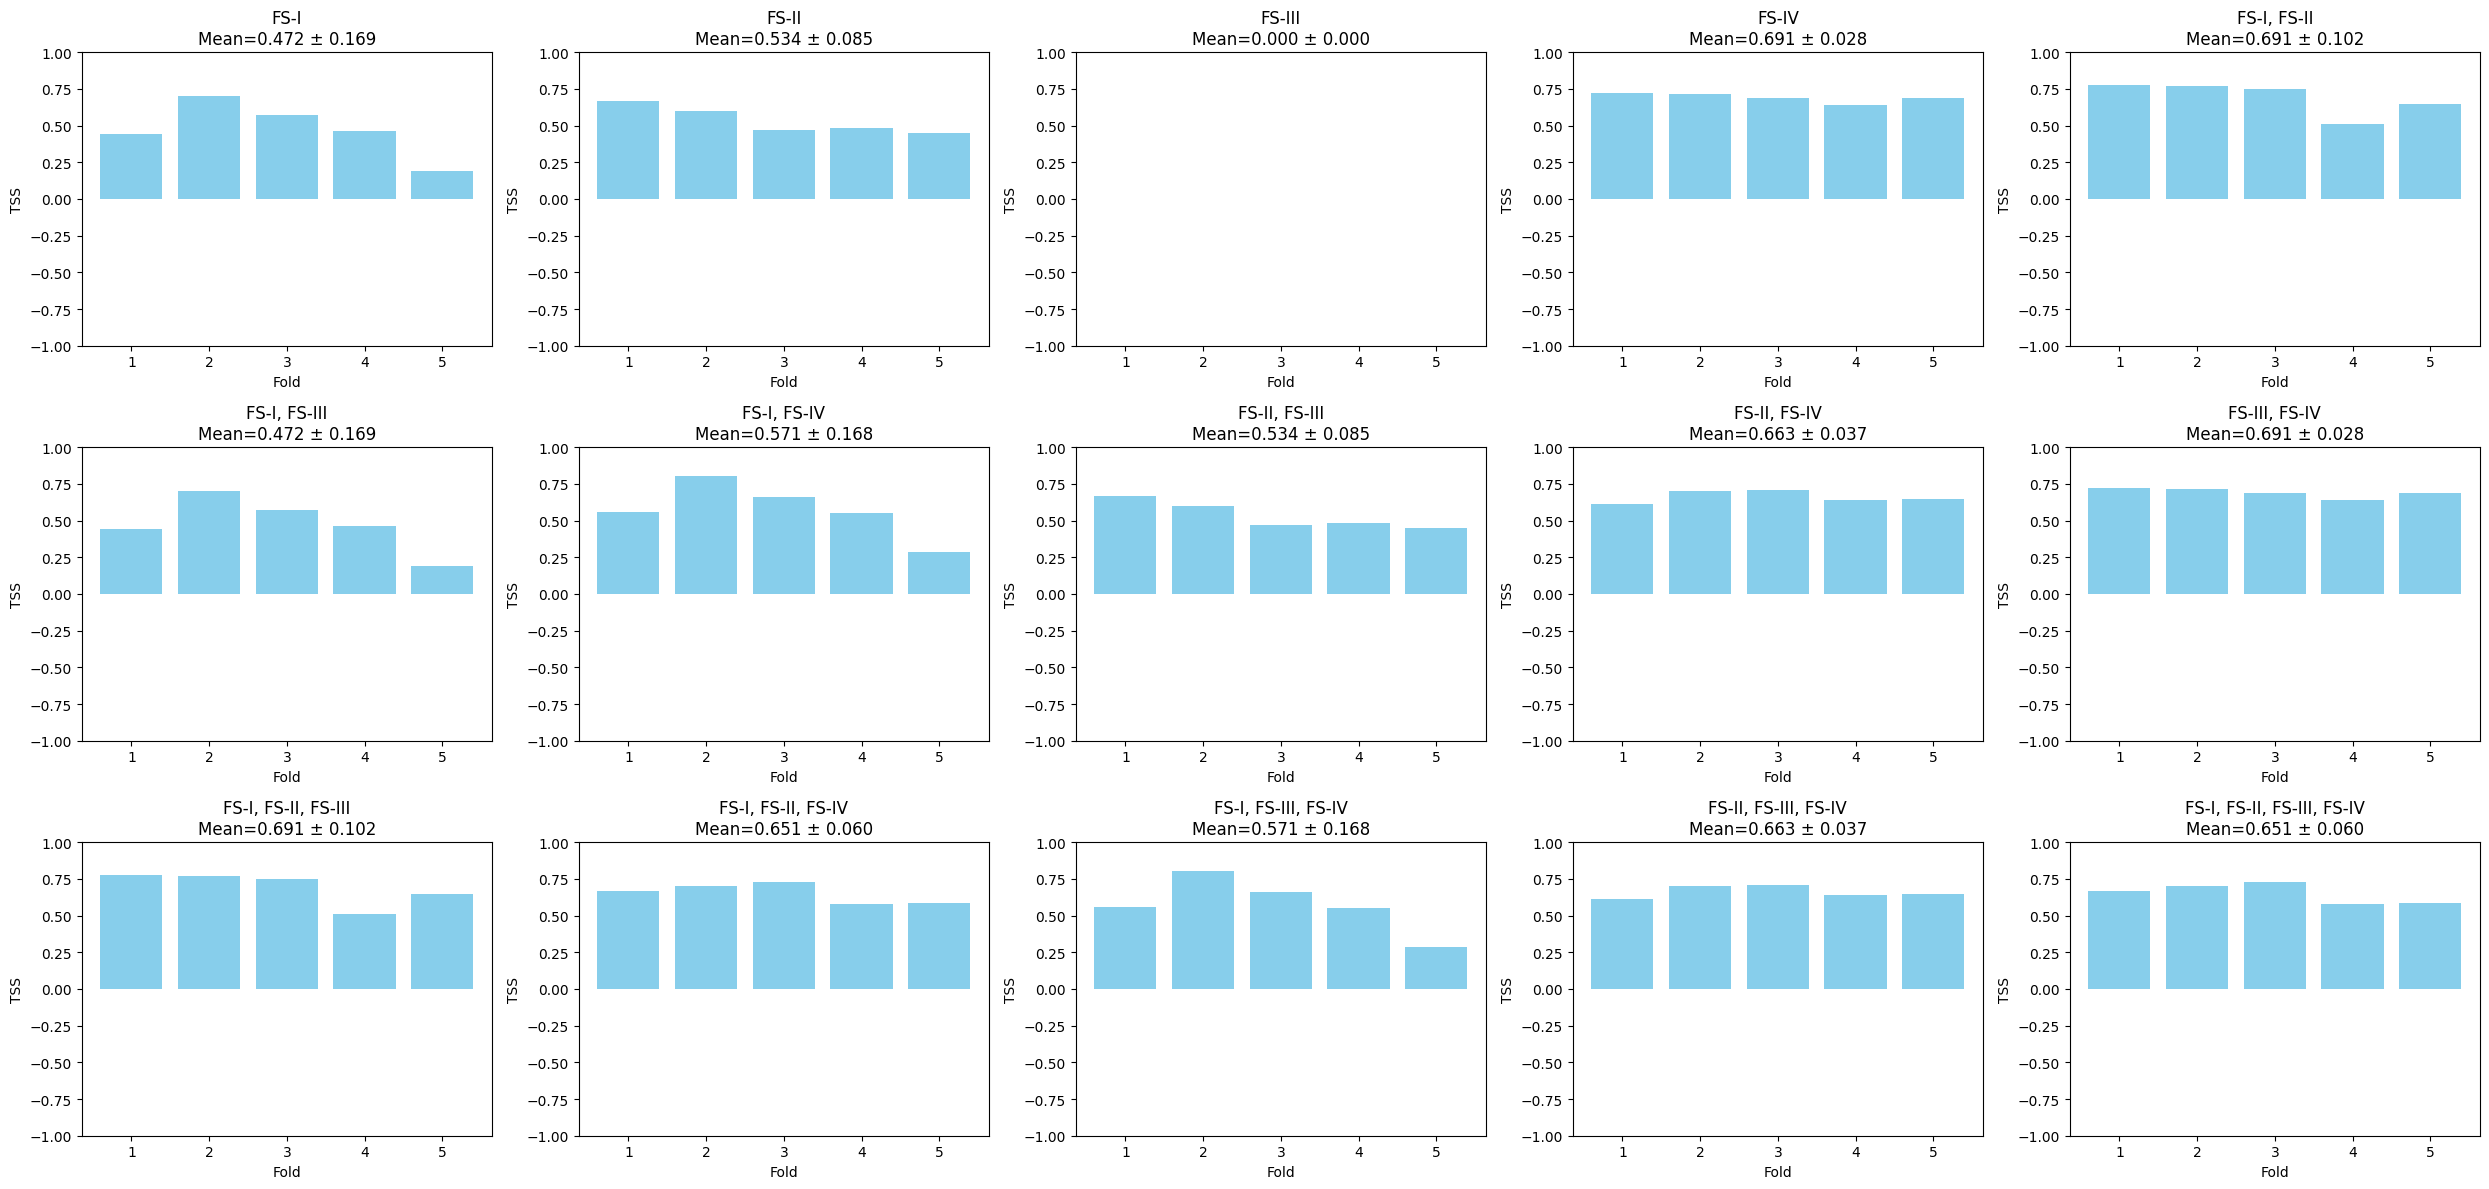

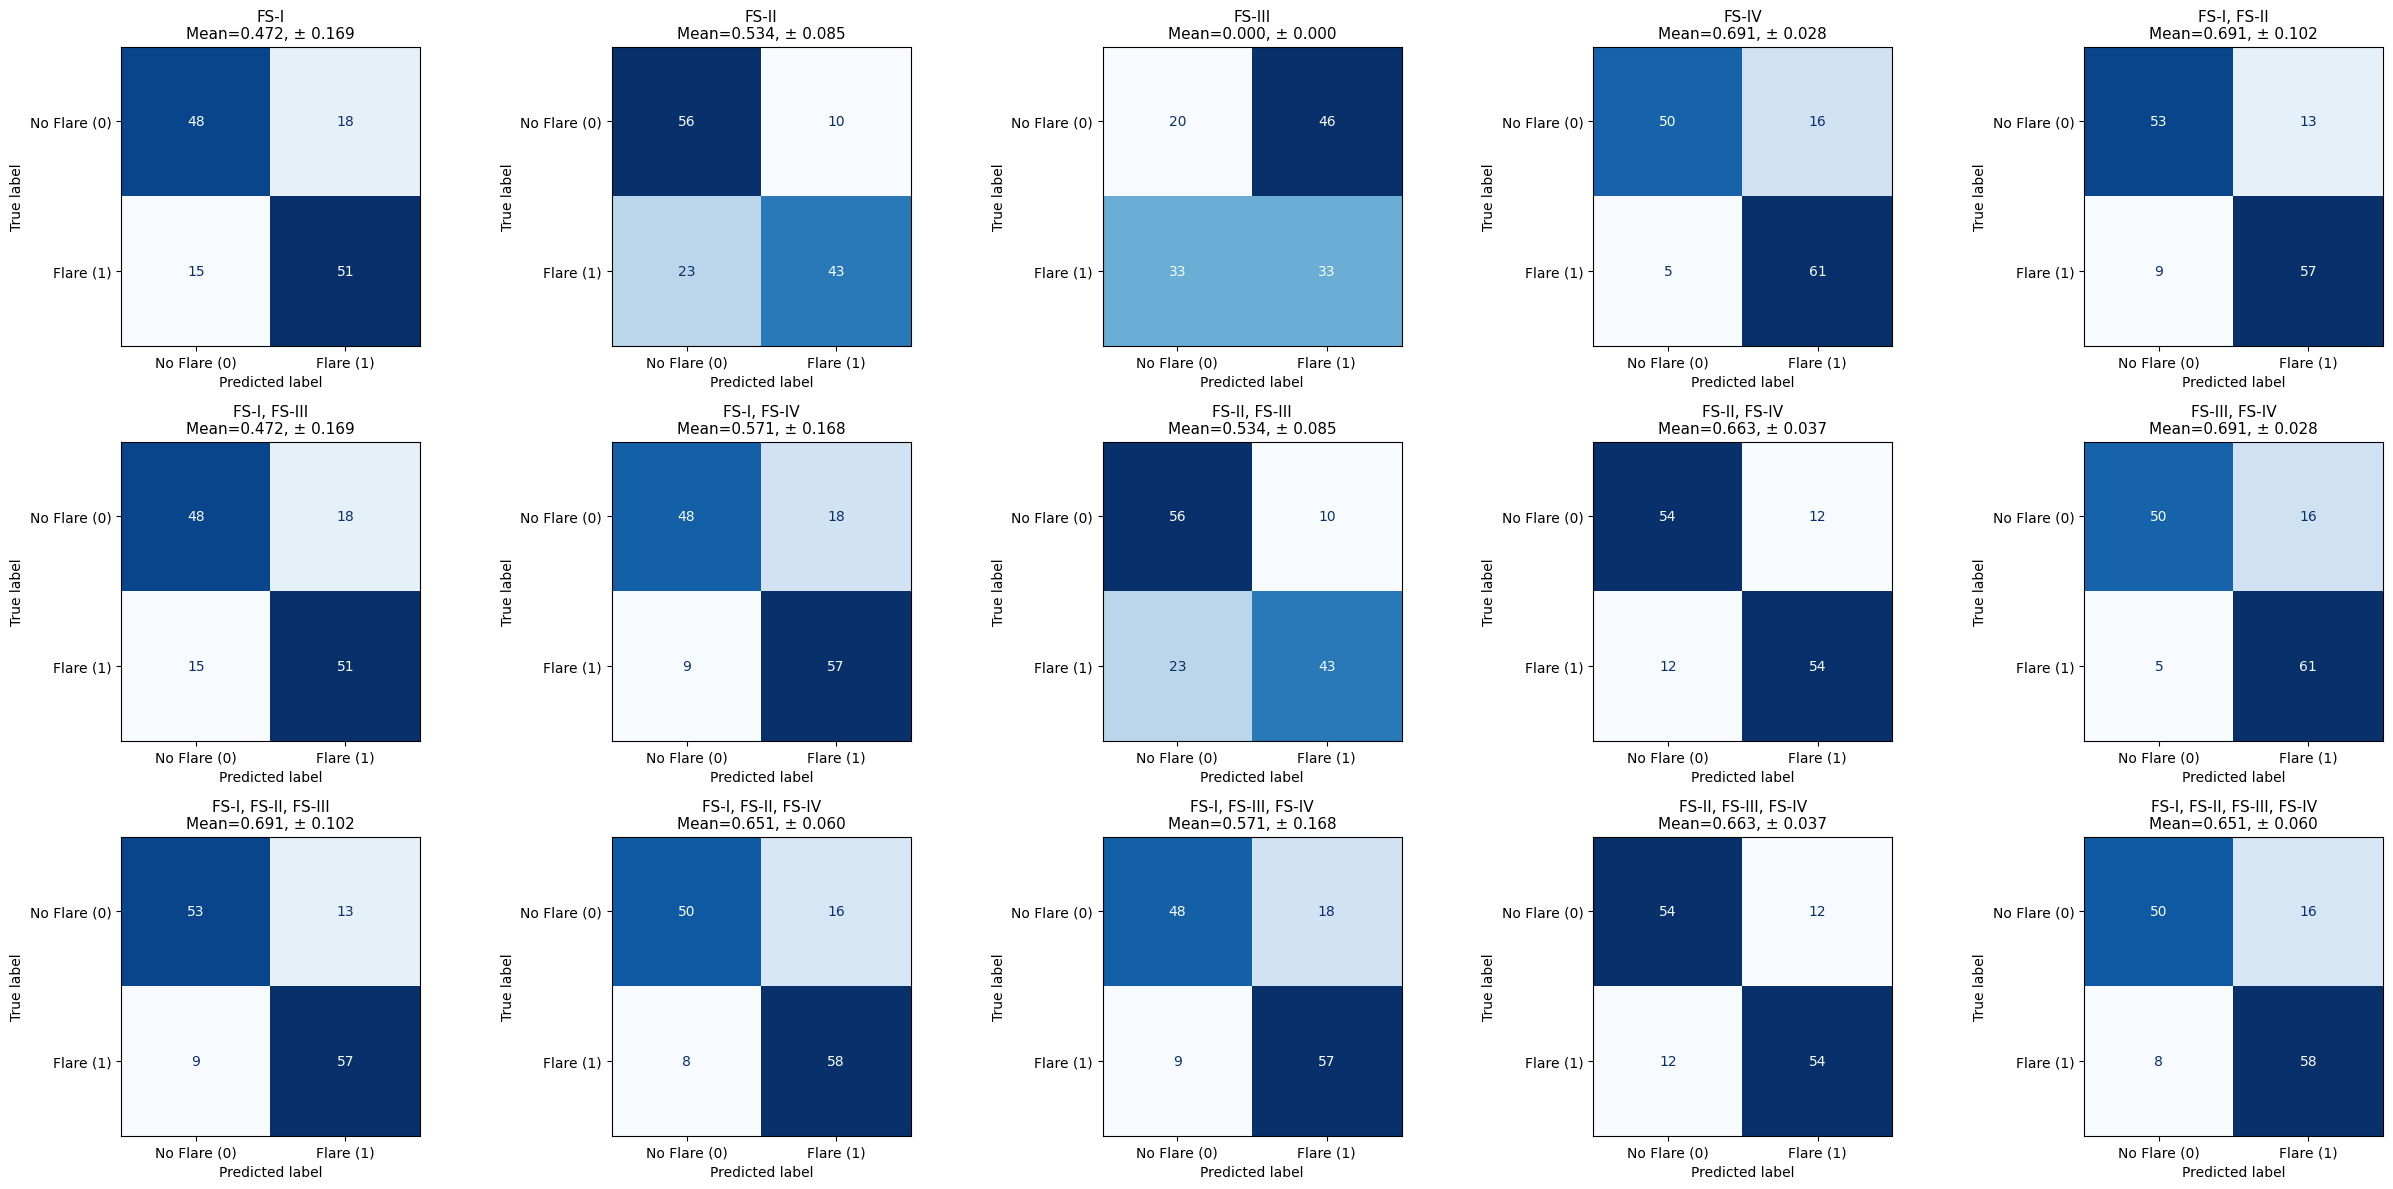


Best performing feature set for data-2020-24: FS-I, FS-II with Avg TSS = 0.6910 ± 0.1017

 Data experiments complete for all datasts


In [6]:
# _____ 1 pt _____ (Clear printed output (best feature set, dataset comparison))
# _____ 1 pt _____ (Visualizations labeled and interpretable)

# below should be your code to call the above classes and functions
# with various combinations of feature sets
# and both datasets

# CODE HERE !

###########

feature_experiment()

data_experiment()



<span style="color:blue; font-size:20px; font-weight:bold">Final Total Score</span><br>
<span style="color:red; font-size:18px">**____ / 25**</span>
</div>